# W1 · Dos preguntas para investigar el gasto educativo

**Grupo 03 · Javier Alcaíno, Lucas Riquelme y Renato Varela · 25-09-2026.** Este W1 se apoya en la investigación previa del equipo. Cuaderno ejecutable con los datos incluidos en `data/`. Pregunta A: custodia de equipos de Melipeuco (2020–2023). Pregunta B: alcance e implementación declarada de acciones PME 2024. Se trata de preguntas y unidades distintas; ninguna correlación aquí mide efecto causal ni convierte planificación en gasto pagado.

## 1. Fuentes, unidades y verificación inicial

A: una fila de compras es una partida destino–documento–modelo del anexo 1; una fila observada es un equipo de los numerales 10.a–c. B: una fila PME es una acción declarada; el directorio tiene un RBD por escuela y año. Las columnas conservan `fila_excel` o `pagina_pdf` para volver a la fuente. El resumen CGR proviene de un caso elegido por hallazgo, no de muestra nacional.

In [1]:
from pathlib import Path
import sys, os, json
import pandas as pd
from IPython.display import display, Image
ROOT=Path.cwd()
if not (ROOT/'data').exists(): ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'analysis'))
from w1_analisis import main
metrics=main()
print('Carpeta:',ROOT.name)
display(pd.DataFrame([metrics['a']]).T.rename(columns={0:'Valor A'}).head(12))

A: comprados 776 observados 628 coincidencias con comodato 476
B: acciones 129726 RBD 8240 piloto 134 acciones
Verificaciones: importes CGR, clave única en anexos, unión RBD y extremos, OK
Carpeta: GROUP_03_W1


Matplotlib is building the font cache; this may take a moment.


,Valor A
partidas,2.900000e+01
equipos_adquiridos,7.760000e+02
valor_partidas_clp,1.761640e+08
valor_impreso_cgr_clp,1.761640e+08
equipos_observados,6.280000e+02
valor_observado_clp,1.364054e+08
porcentaje_equipos_observados,8.092784e+01
porcentaje_valor_observado,7.743089e+01
comodatos,6.000000e+02
coincidencias,4.760000e+02


## 2. Línea A · ¿Dónde se interrumpe la custodia?

El denominador de 776 equipos y $176.164.029 es el universo histórico auditado por CGR, no el gasto de Chile. La suma de partidas extraídas difiere $1 del total impreso: ambas cifras se conservan. El cruce por factura y serie verifica certificados que coexisten con la observación de no habido; no demuestra que el equipo nunca se utilizó.

Cruce exacto con comodato: 476 de 600


,observacion,equipos,valor_observado_clp
0,10.a,625,136000454
1,10.b,2,164734
2,10.c,1,240190


,familia,equipos,valor_observado_clp
0,Lenovo P11 + teclado/lápiz,231,80849769
1,Samsung A8/T295,338,47874176
2,Asus portátil,5,3656535
3,Huawei T3,19,1564973
4,Mlab 7,29,1304159
5,Lenovo M8,4,606176
6,Samsung A7,1,309400
7,Impresora Epson,1,240190


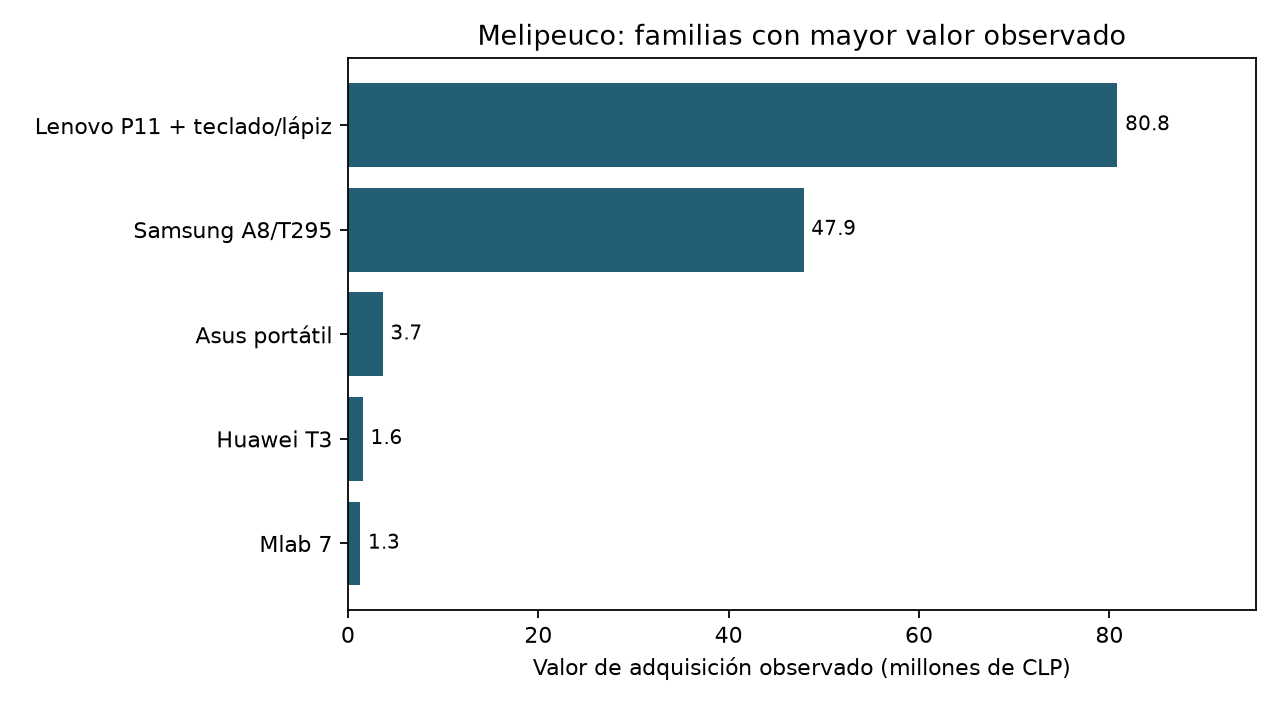

In [2]:
familias=pd.read_csv(ROOT/'analysis/outputs/a_familias_observadas.csv')
estados=pd.read_csv(ROOT/'analysis/outputs/a_tipos_observacion.csv')
display(estados)
display(familias.head(8))
display(Image(filename=str(ROOT/'analysis/outputs/a_valor_observado.png')))
print('Cruce exacto con comodato:',metrics['a']['coincidencias'],'de',metrics['a']['comodatos'])

**Lectura:** los 628 equipos observados representan 80,93% de las unidades auditadas; las Lenovo P11 concentran $80,85 millones de valor histórico observado. La pregunta de decisión es recuperar, localizar o justificar la baja de los activos, especialmente de las familias más materiales. El seguimiento posterior y la utilización anterior no constan en estos anexos.

## 3. Línea B · ¿Qué muestra el PME 2024?

Los montos `ESTIM_TOTAL` son estimaciones declaradas, no transferencias, pagos ni aceptación de rendición. `NIV_IMPLEM` son tramos autodeclarados; aquí sólo se identifica explícitamente el 100%, sin convertir 75–99% en un punto exacto.

,DIMENSION,acciones,escuelas,estimacion_mediana_clp,porcentaje_completo
0,Convivencia Escolar,31839,8240,1800000.0,65.570527
1,Gestión Pedagógica,39425,8240,2000000.0,65.384908
2,Gestión de Recursos,31083,8240,6000000.0,64.099347
3,Liderazgo,27379,8240,750000.0,63.066584


,COD_DEPE,escuelas_directorio,escuelas_pme,cobertura_pct
1,2,3275,3128,95.511450
2,3,5440,3499,64.319853
5,6,830,799,96.265060


,escenario,acciones,estimacion_total_clp,estimacion_media_clp,estimacion_mediana_clp
0,Todos los registros,129726,1713979868012,1.321231e+07,2000000.0
1,Excluir acciones > $1.000 millones,129707,1494670497529,1.152344e+07,2000000.0


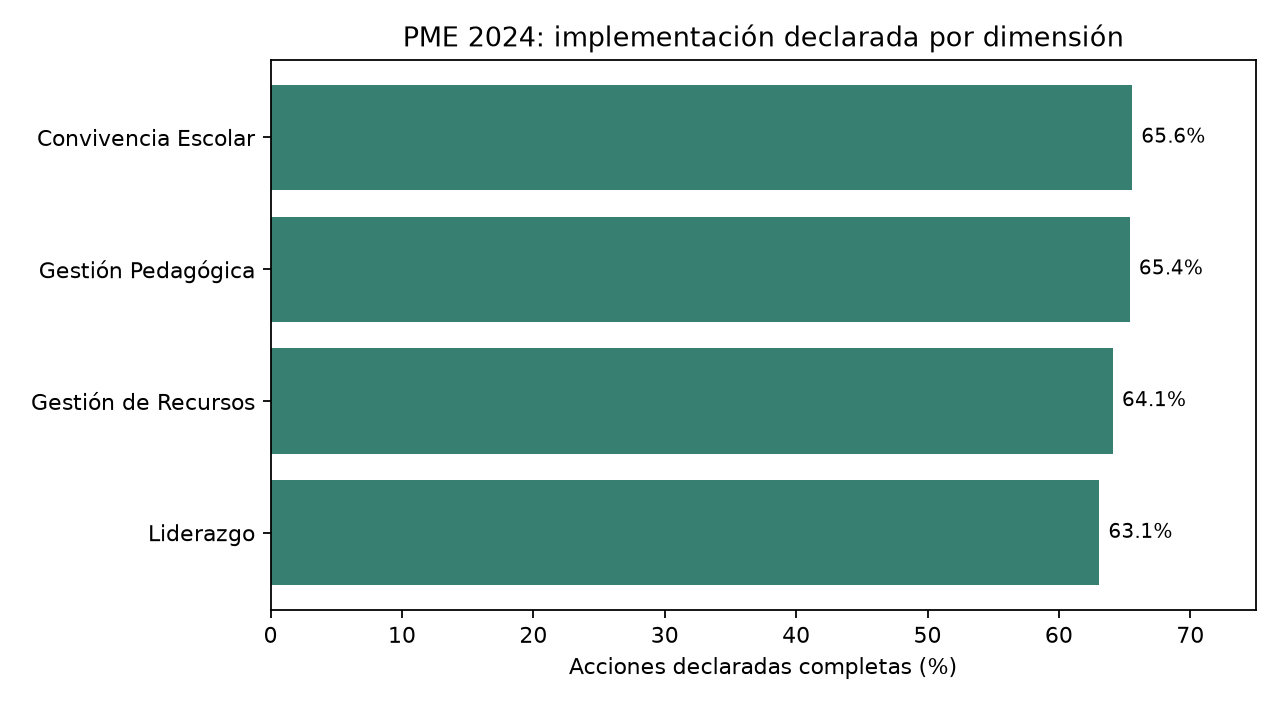

In [3]:
dims=pd.read_csv(ROOT/'analysis/outputs/b_resumen_dimensiones.csv')
cob=pd.read_csv(ROOT/'analysis/outputs/b_cobertura_dependencia.csv')
sens=pd.read_csv(ROOT/'analysis/outputs/b_sensibilidad_extremos.csv')
display(dims[['DIMENSION','acciones','escuelas','estimacion_mediana_clp','porcentaje_completo']])
display(cob[cob.COD_DEPE.isin([2,3,6])])
display(sens)
display(Image(filename=str(ROOT/'analysis/outputs/b_implementacion_dimensiones.png')))

In [4]:
cis=pd.read_csv(ROOT/'analysis/outputs/b_panel_cisterna.csv')
display(cis[['RBD','NOM_RBD','acciones','estimacion_total_clp','fraccion_completa','MAT_TOTAL','estimacion_por_alumno_clp']].sort_values('RBD'))
print('Unión nacional de RBD comprobada:',metrics['b']['escuelas_union_verificada'],'/',metrics['b']['escuelas'])

Unión nacional de RBD comprobada: 8240 / 8240


,RBD,NOM_RBD,acciones,estimacion_total_clp,fraccion_completa,MAT_TOTAL,estimacion_por_alumno_clp
0,9693,LICEO POLITECNICO CIENCIA Y TECNOLOGIA,14,487400000,0.928571,848,574764.150943
1,9699,COLEGIO NACIONES UNIDAS,18,224000000,0.888889,307,729641.693811
2,9700,COLEGIO PALESTINO,12,136435996,0.250000,342,398935.660819
3,9701,LICEO POLIVALENTE OLOF PALME,17,213794000,1.000000,449,476155.902004
4,9703,ESCUELA ESPERANZA JOVEN,19,168729000,0.894737,322,524003.105590
5,9706,ESCUELA BAS. OSCAR ENCALADA YOVANOVICH,13,65000000,0.000000,307,211726.384365
6,9722,LICEO PORTAL DE LA CISTERNA,20,123800000,0.100000,463,267386.609071
7,9730,COLEGIO ANTU,21,156824000,0.285714,322,487031.055901


**Lectura:** se inspeccionaron 129.726 acciones de 8.240 RBD; 134 acciones corresponden a los ocho RBD públicos seleccionados de La Cisterna. Gestión de Recursos tiene la mediana estimada más alta por acción ($6 millones), pero no implica más gasto efectivo. Las 19 acciones >$1.000 millones suman 12,80% de la estimación total; deben verificarse antes de usar medias. La cobertura PME varía por dependencia, por lo que no extrapolamos las tasas a todo el sistema.

## 4. Calidad, uniones y continuidad

**Five Cs:** Clean: fechas/montos y extremos; Consistent: RBD, fondo y año; Complete: 38 `ESTIM_SEP` ausentes y series de activos no identificables; Current: compra 2020–2022, visita 2023 y PME/directorio 2024 no forman un mismo período; Collaborative: diccionario, URLs, página/fila y supuestos legibles.

**Uniones:** PME agrupado por RBD ↔ directorio 2024 quedó verificado 8.240/8.240; `MATRICULA` binaria no se usa como conteo (se usa `MAT_TOTAL`). Factura + serie de anexos CGR produjo 476 coincidencias exactas, sin equivaler a disponibilidad. Unir compras a acción PME por texto, o gastos 2021 a matrícula 2024, queda rechazado sin evidencia de beneficiario y período.

**Para C1:** preferencia provisional A por trazabilidad física y monetaria, con la limitación de que Melipeuco fue seleccionado por un hallazgo. B permite estudiar calidad del registro y planificación, pero no juzgar si el gasto estuvo bien invertido. Los futuros modelos y tableros se tratan como hipótesis sujetas a nuevas fuentes.